In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, roc_auc_score
import warnings
warnings.filterwarnings("ignore")
sns.set(style="whitegrid")

/kaggle/input/competitions/playground-series-s6e10/sample_submission.csv
/kaggle/input/competitions/playground-series-s6e10/train.csv
/kaggle/input/competitions/playground-series-s6e10/test.csv


In [2]:
train_df = pd.read_csv("/kaggle/input/competitions/playground-series-s6e10/train.csv")
test_df = pd.read_csv("/kaggle/input/competitions/playground-series-s6e10/test.csv")

print("训练集形状：", train_df.shape)
print("测试集形状：", test_df.shape)
train_df.head()

训练集形状： (699635, 23)
测试集形状： (299844, 22)


,id,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,...,Baggage handling,Checkin service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,Gender,Customer Type,Type of Travel,Class,satisfaction
0,0,36,694,4,4,4,3,1,4,1,...,4,3,1,0,0.0,Female,Loyal Customer,Personal Travel,Eco,False
1,1,56,651,5,5,5,5,5,4,4,...,5,4,3,0,0.0,Male,Loyal Customer,Business travel,Business,True
2,2,31,1371,3,4,2,5,3,3,3,...,4,5,3,0,0.0,Female,Loyal Customer,Personal Travel,Eco,False
3,3,10,1616,3,5,3,3,3,3,3,...,3,4,3,0,0.0,Male,Loyal Customer,Personal Travel,Eco,False
4,4,23,481,3,4,3,4,5,3,5,...,5,3,5,5,0.0,Female,disloyal Customer,Business travel,Eco,False


观察数据的类型是数值还是分类，哪些数据有缺失。

In [3]:
train_df.info()
print(train_df["satisfaction"].value_counts())
train_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 699635 entries, 0 to 699634
Data columns (total 23 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   id                                 699635 non-null  int64  
 1   Age                                699635 non-null  int64  
 2   Flight Distance                    699635 non-null  int64  
 3   Inflight wifi service              699635 non-null  int64  
 4   Departure/Arrival time convenient  699635 non-null  int64  
 5   Ease of Online booking             699635 non-null  int64  
 6   Gate location                      699635 non-null  int64  
 7   Food and drink                     699635 non-null  int64  
 8   Online boarding                    699635 non-null  int64  
 9   Seat comfort                       699635 non-null  int64  
 10  Inflight entertainment             699635 non-null  int64  
 11  On-board service                   6996

,id,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
count,699635.000000,699635.000000,699635.000000,699635.000000,699635.00000,699635.00000,699635.000000,699635.000000,699635.000000,699635.000000,699635.000000,699635.000000,699635.000000,699635.000000,699635.000000,699635.000000,699635.000000,699343.000000
mean,349817.000000,39.001928,1353.778702,2.778722,3.15621,2.81324,3.013734,3.265644,3.364156,3.568950,3.453910,3.517404,3.472847,3.805443,3.420291,3.380401,1.176209,1.134280
std,201967.372129,13.800943,954.422566,1.280419,1.47539,1.32955,1.254014,1.300202,1.288538,1.275333,1.308157,1.238474,1.271755,1.079175,1.210604,1.277870,5.982187,5.749304
min,0.000000,7.000000,67.000000,0.000000,0.00000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,174908.500000,27.000000,631.000000,2.000000,2.00000,2.00000,2.000000,2.000000,2.000000,3.000000,2.000000,3.000000,2.000000,3.000000,3.000000,2.000000,0.000000,0.000000
50%,349817.000000,40.000000,954.000000,3.000000,3.00000,3.00000,3.000000,3.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,0.000000,0.000000
75%,524725.500000,50.000000,1814.000000,4.000000,4.00000,4.00000,4.000000,4.000000,4.000000,5.000000,5.000000,4.000000,5.000000,5.000000,4.000000,4.000000,0.000000,0.000000
max,699634.000000,85.000000,4983.000000,5.000000,5.00000,5.00000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,489.000000,491.000000


In [4]:
train = train_df.copy()
test = test_df.copy()

# 保存测试集 id
test_id = test["id"]

# 分离目标变量
y = train["satisfaction"]
X = train.drop(columns=["satisfaction", "id"])
X_test = test.drop(columns=["id"])

# 如果有字符串类型的分类列，转成数值
for col in X.columns:
    if X[col].dtype == "object":
        # 用训练集的众数填充缺失
        X[col] = X[col].fillna(X[col].mode()[0])
        X_test[col] = X_test[col].fillna(X[col].mode()[0])
        # 把训练集和测试集合并后做 One-Hot，保证列一致
        combined = pd.concat([X[col], X_test[col]], axis=0)
        combined = pd.get_dummies(combined, drop_first=True)
        X = X.drop(columns=[col]).join(combined.iloc[:len(X)])
        X_test = X_test.drop(columns=[col]).join(combined.iloc[len(X):].reset_index(drop=True))

# 数值列的缺失值用中位数填充
for col in X.columns:
    if X[col].dtype != "object":
        X[col] = X[col].fillna(X[col].median())
        X_test[col] = X_test[col].fillna(X[col].median())

print("特征数量：", X.shape[1])

特征数量： 22


随机森林模型

In [5]:
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    class_weight="balanced",   # 自动调整类别权重
    random_state=42,
    n_jobs=-1
)
model.fit(X, y)

train_pred = model.predict(X)
print("训练集准确率：", accuracy_score(y, train_pred))

训练集准确率： 0.929160204964017


交叉验证训练集准确性。

In [6]:
cv_scores = cross_val_score(model, X, y, cv=5, scoring="accuracy")
print("交叉验证准确率：", cv_scores)
print("平均准确率：", cv_scores.mean())

交叉验证准确率： [0.92341006 0.92261679 0.92252389 0.92100881 0.92215227]
平均准确率： 0.9223423642327786


查看各项特征重要性。

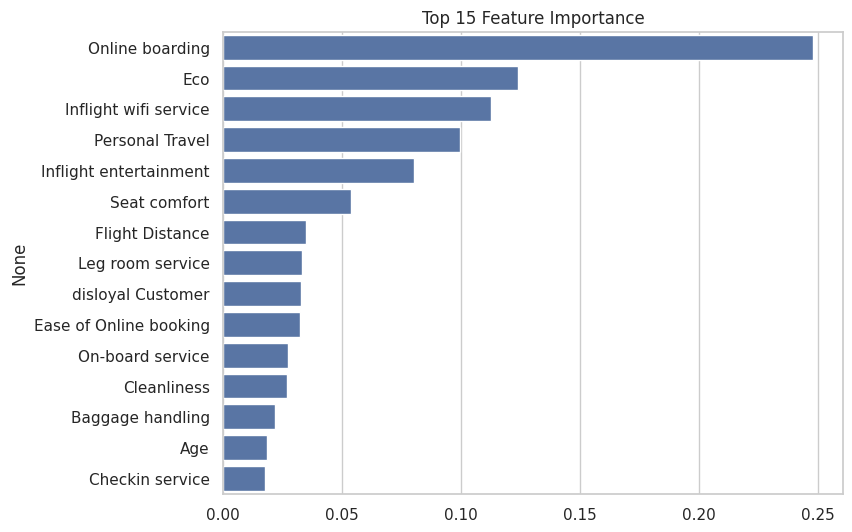

Online boarding           0.248169
Eco                       0.123956
Inflight wifi service     0.112492
Personal Travel           0.099793
Inflight entertainment    0.080183
Seat comfort              0.053897
Flight Distance           0.034743
Leg room service          0.033095
disloyal Customer         0.032779
Ease of Online booking    0.032392
On-board service          0.027331
Cleanliness               0.026962
Baggage handling          0.022007
Age                       0.018620
Checkin service           0.017908
dtype: float64


In [7]:
importances = pd.Series(model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(x=importances.values[:15], y=importances.index[:15])
plt.title("Top 15 Feature Importance")
plt.show()

print(importances.head(15))

In [8]:
# 用 predict_proba 获取正类（满意=1）的概率
test_pred_proba = model.predict_proba(X_test)[:, 1]

# 构造提交文件，列名必须严格对齐 sample_submission.csv
submission = pd.DataFrame({
    "id": test_id,
    "satisfaction": test_pred_proba
})

submission.to_csv("/kaggle/working/submission.csv", index=False)
print("Submission exported to /kaggle/working/submission.csv")
print(submission.head())

Submission exported to /kaggle/working/submission.csv
       id  satisfaction
0  699635      0.311432
1  699636      0.912453
2  699637      0.809535
3  699638      0.077619
4  699639      0.077728


In [9]:
sample = pd.read_csv("/kaggle/input/competitions/playground-series-s6e10/sample_submission.csv")
print(sample.head())

       id  satisfaction
0  699635      0.443573
1  699636      0.443573
2  699637      0.443573
3  699638      0.443573
4  699639      0.443573
